# P667 – Amazon Review Sentiment Analysis
## EDA & Preprocessing

**Team:** Group 2 | **Mentor:** Sadiya Ansari | **Dataset:** 1,440 Amazon reviews

---

### What we're doing

We have 1,440 Amazon reviews with three columns: `title`, `rating` (1–5 stars), and `body` (the review text). Our job is to build a model that reads review text and predicts sentiment.

**Feature vs label — the core distinction:**
- **`body`** → the FEATURE. What the model reads.
- **`rating`** → used to DERIVE the LABEL. Converted into positive/negative categories so the model has an answer to learn from. Never used as a feature (that would be data leakage).

### Notebook flow

1. Load & inspect
2. EDA — understand before changing
3. Clean text
4. Engineer labels (binary + three-class)
5. Split & vectorize with TF-IDF
6. Export

## 1. Load & Inspect

Confirm shape, types, nulls, and duplicates before any other work.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
SEED = 42

df = pd.read_excel("dataset -P667.xlsx")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Dtypes:\n{df.dtypes}\n")
print(f"Null counts:\n{df.isnull().sum()}")
print(f"\nDuplicate bodies: {df.duplicated(subset='body').sum()}")
print(f"Unique titles: {df['title'].nunique()} / {len(df)}")
df.head(3)

Shape: (1440, 3)
Columns: ['title', 'rating', 'body']
Dtypes:
title       str
rating    int64
body        str
dtype: object

Null counts:
title     0
rating    0
body      0
dtype: int64

Duplicate bodies: 0
Unique titles: 1351 / 1440


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance from Samsung
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must be appreciatedCamera is just averageMobile performance is above avera..."


## 2. Exploratory Data Analysis

> **Why EDA first?** If we clean before understanding, we destroy evidence of what was wrong. Every cleaning step below is justified by something we see in this section.

**Three questions we're answering:**
1. Are classes balanced?
2. What noise needs cleaning?
3. Does the title column add signal beyond the body?

### 2.1 Rating Distribution & Review Length

Class balance tells us whether accuracy alone can be trusted. Length tells us whether we need to set a `max_length` for transformers downstream.

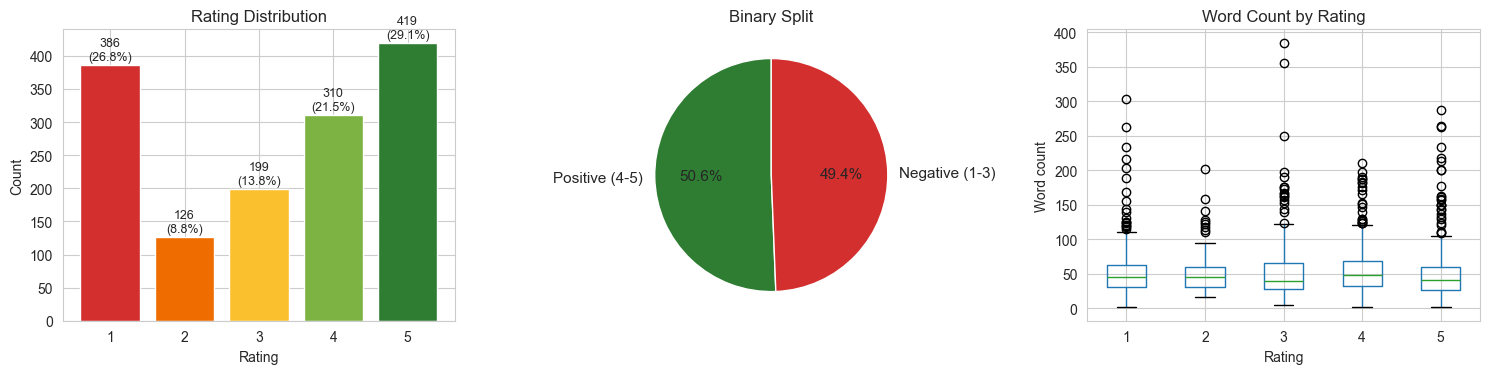

Binary split — negative: 711 (49.4%), positive: 729 (50.6%)
Word count — median: 43, 75th: 63, max: 385


In [2]:
df["body_words"] = df["body"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
rating_counts = df["rating"].value_counts().sort_index()
colors = ["#d32f2f", "#ef6c00", "#fbc02d", "#7cb342", "#2e7d32"]
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor="white")
for r, c in rating_counts.items():
    axes[0].text(r, c + 8, f"{c}\n({c/len(df)*100:.1f}%)", ha="center", fontsize=9)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].set_title("Rating Distribution")
axes[0].set_xticks([1, 2, 3, 4, 5])

# Binary split
binary_counts = [(df["rating"] >= 4).sum(), (df["rating"] < 4).sum()]
axes[1].pie(binary_counts, labels=["Positive (4-5)", "Negative (1-3)"],
            autopct="%1.1f%%", colors=["#2e7d32", "#d32f2f"],
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Binary Split")

# Length by rating
df.boxplot(column="body_words", by="rating", ax=axes[2])
axes[2].set_xlabel("Rating")
axes[2].set_ylabel("Word count")
axes[2].set_title("Word Count by Rating")
plt.suptitle("")

plt.tight_layout()
plt.show()

print(f"Binary split — negative: {binary_counts[1]} ({binary_counts[1]/len(df)*100:.1f}%), "
      f"positive: {binary_counts[0]} ({binary_counts[0]/len(df)*100:.1f}%)")
print(f"Word count — median: {df['body_words'].median():.0f}, 75th: {df['body_words'].quantile(0.75):.0f}, "
      f"max: {df['body_words'].max():.0f}")

**Findings:**
- Binary split is nearly **50/50** — unusually balanced for Amazon. Accuracy will be trustworthy here.
- Three-class is skewed: neutral (3-star) will be only ~14% and hardest for models to learn.
- Length is moderate across ratings (median 43 words). DistilBERT `max_length=128` will fit most reviews.

### 2.2 Text Quality: What Noise Needs Cleaning?

Models treat every character as signal. Boilerplate phrases that appear across all ratings waste feature space and confuse the model.

In [3]:
# Non-ASCII ratio for detecting non-English reviews
df["non_ascii_pct"] = df["body"].apply(
    lambda x: len(re.findall(r"[^\x00-\x7F]", str(x))) / max(len(str(x)), 1)
)

noise_checks = {
    '"media could not be loaded" boilerplate': df["body"].str.contains("media could not be loaded", case=False).sum(),
    "HTML tags": df["body"].str.contains(r"<[^>]+>", regex=True).sum(),
    "URLs": df["body"].str.contains(r"http[s]?://", regex=True).sum(),
    "Hashtags": df["body"].str.contains(r"#\w+", regex=True).sum(),
    "Any non-ASCII chars (emojis, Hindi)": (df["non_ascii_pct"] > 0).sum(),
    "Fully non-English (>30% non-ASCII)": (df["non_ascii_pct"] > 0.3).sum(),
    "Reviews < 5 words": (df["body_words"] < 5).sum(),
}

noise_df = pd.DataFrame(list(noise_checks.items()), columns=["Pattern", "Count"])
noise_df["% of data"] = (noise_df["Count"] / len(df) * 100).round(1)
print(noise_df.to_string(index=False))

# Sample a few fully-Hindi reviews to confirm
print("\nSample fully non-English reviews:")
for _, r in df[df["non_ascii_pct"] > 0.3].head(2).iterrows():
    print(f"  [{r['rating']} star] {r['body'][:100]}...")

                                Pattern  Count  % of data
"media could not be loaded" boilerplate     34        2.4
                              HTML tags      1        0.1
                                   URLs      2        0.1
                               Hashtags      5        0.3
    Any non-ASCII chars (emojis, Hindi)    193       13.4
     Fully non-English (>30% non-ASCII)     13        0.9
                      Reviews < 5 words     17        1.2

Sample fully non-English reviews:
  [1 star] मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बताया और क्लियरिटी 5 मेगा पिक्सल का भी नही है ।मोबाइल भी...
  [1 star] Damage product reshived hua hai or koi help nahi ki ja rahi haiअमेजॉन से प्रोडक्ट मंगाया था यह अभी त...


**Decisions from the noise scan:**

| Pattern | Decision | Why |
|---|---|---|
| Boilerplate, HTML, URLs, hashtag symbols | **Strip** | Pure noise, no sentiment signal |
| Emojis / mixed-script reviews | **Strip emojis, keep English** | English portions still carry signal |
| 13 fully Hindi reviews | **Drop** | English-trained models can't learn from them (<1% of data) |
| 17 ultra-short reviews | **Keep** | "Dislike", "Best mobile" still carry sentiment |

### 2.3 Does the Title Column Add Signal?

If titles are just summaries of the body, they're redundant. If they carry distinct sentiment, we should combine them as a feature.

In [4]:
print("Most common titles:")
print(df["title"].value_counts().head(8).to_frame())

print("\nSample title-body pairs:")
for _, r in df.sample(4, random_state=SEED).iterrows():
    print(f"  [{r['rating']} star] Title: {r['title'][:55]}")
    print(f"         Body:  {r['body'][:75]}...\n")

Most common titles:
                 count
title                 
Value for money     16
Average              6
Waste of money       6
Good                 6
Awesome phone        5
Good product         5
Good phone           5
Excellent            4

Sample title-body pairs:
  [5 star] Title: Awesome phone, very long battery life, great feel
         Body:  I am writing this review after 3 days of usage. I have upgraded to this pho...

  [3 star] Title: Phone is heavy and camera quality not good
         Body:  Phone camera is not worth the quality mentioned and the device is also havi...

  [5 star] Title: Phone is Extravagently cool and strong.
         Body:  Everything is very good som people said processor is not good but it's abso...

  [2 star] Title: It is USB 2.0 enabled device and not MHL compatible
         Body:  I bought this phone mainly for my kids online class during this pandemic. W...



**Finding:** Titles are mostly unique (1,351 / 1,440) and carry strong standalone sentiment — "Waste of money", "Awesome phone". They often state the verdict while the body explains reasoning.

**Plan:** Create a `text_combined = title + body` variant and test both in modeling.

## 3. Text Cleaning

Every step below is justified by a finding in section 2.

**What we deliberately skip:** lowercasing, stopword removal, stemming, spell-correction. TF-IDF handles case/stopwords via its parameters; transformers need the original text. Over-cleaning destroys linguistic signal.

In [5]:
# Drop the 13 fully-Hindi reviews (design decision from 2.2)
df = df[df["non_ascii_pct"] <= 0.3].copy().reset_index(drop=True)
print(f"Rows after dropping non-English: {len(df)}")


def clean_text(text: str) -> str:
    """Clean a single review — order matters, strip structured noise first."""
    text = re.sub(r"The media could not be loaded\.\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"<[^>]+>", " ", text)                 # HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # URLs
    text = re.sub(r"#", "", text)                         # # symbol, keep hashtag word
    text = re.sub(r"[^\x00-\x7F]+", " ", text)          # emojis & non-ASCII
    text = re.sub(r"\s+", " ", text)                     # collapse whitespace
    return text.strip()


df["body_clean"] = df["body"].astype(str).apply(clean_text)
df["title_clean"] = df["title"].astype(str).apply(clean_text)
df["text_combined"] = df["title_clean"] + " . " + df["body_clean"]

# Sanity checks
print(f"Empty bodies after cleaning: {(df['body_clean'].str.len() == 0).sum()}")
print(f"Boilerplate remaining: {df['body_clean'].str.contains('media could not be loaded', case=False).sum()}")

print("\nBefore/After example:")
print(f"  BEFORE: {df['body'].iloc[2][:140]}")
print(f"  AFTER:  {df['body_clean'].iloc[2][:140]}")

Rows after dropping non-English: 1427
Empty bodies after cleaning: 0
Boilerplate remaining: 0

Before/After example:
  BEFORE: Got the mobile on the launch date,Battery must be appreciatedCamera is just averageMobile performance is above average90hz refresh rate? If 
  AFTER:  Got the mobile on the launch date,Battery must be appreciatedCamera is just averageMobile performance is above average90hz refresh rate? If 


## 4. Label Engineering

Convert the `rating` column into sentiment labels. From here on, `rating` is the label **source** only — never a feature.

**Two schemes to compare** (per Sadiya's instruction):
- **Binary:** 1–3 → negative, 4–5 → positive. Near-perfect balance, simpler for models.
- **Three-class:** 1–2 → negative, 3 → neutral, 4–5 → positive. Richer output but neutral is only ~14% — harder to learn.

We'll evaluate with **macro F1**, which averages F1 per class — a model that ignores the neutral class will score poorly on it, unlike accuracy.

In [6]:
df["label_binary"] = (df["rating"] >= 4).astype(int)
df["label_three"] = df["rating"].map({1: 0, 2: 0, 3: 1, 4: 2, 5: 2})

print("=== Binary ===")
for val, name in {0: "negative", 1: "positive"}.items():
    c = (df["label_binary"] == val).sum()
    print(f"  {name}: {c} ({c/len(df)*100:.1f}%)")

print("\n=== Three-class ===")
for val, name in {0: "negative", 1: "neutral", 2: "positive"}.items():
    c = (df["label_three"] == val).sum()
    print(f"  {name}: {c} ({c/len(df)*100:.1f}%)")

=== Binary ===
  negative: 700 (49.1%)
  positive: 727 (50.9%)

=== Three-class ===
  negative: 501 (35.1%)
  neutral: 199 (13.9%)
  positive: 727 (50.9%)


## 5. Train/Test Split & TF-IDF

### Why split, and why stratify?

Train and test must come from different rows — otherwise the model memorizes instead of learning, and our metrics become lies. We stratify on the label so both splits have the same class ratio; without stratification, a random split could hand us a test set that's 70% positive just by chance, and our metrics would mislead us.

### Why TF-IDF, and what does it actually produce?

Models can't read text. They need numbers. TF-IDF (Term Frequency – Inverse Document Frequency) is a classical way to turn each review into a numeric vector by scoring every word based on two signals:

- **TF:** how often the word appears *in this review*
- **IDF:** how rare the word is *across all reviews*

Multiply them together and you get a score per word. The result: words that are frequent in one review but uncommon overall (like "terrible" in a 1-star review) get **high scores**; words that are everywhere (like "phone" or "the") get **low scores**.

Each review becomes a vector of ~5,000 numbers — one per word/phrase in our vocabulary. Most of those numbers are zero (a short review only mentions a handful of our 5,000 words). The non-zero entries are what tell the model what this review is "about".

### Leakage guard

TF-IDF must be fit on **training data only**. If we fit on the full dataset, vocabulary from the test set leaks into training — like a student peeking at the answer key. Our metrics would look great and then fall apart on new reviews.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Stratified 80/20 split — same class ratio in both splits
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label_binary"],
)
df["split"] = "train"
df.loc[test_idx, "split"] = "test"

print(f"Train: {len(train_idx)}  |  Test: {len(test_idx)}")
print(f"Positive rate — Train: {df.loc[train_idx, 'label_binary'].mean():.3f}  "
      f"Test: {df.loc[test_idx, 'label_binary'].mean():.3f}  "
      f"(stratification confirmed)\n")

# TF-IDF — every parameter below is a deliberate choice for sentiment classification
tfidf = TfidfVectorizer(
    max_features=5000,      # cap vocab size — with only ~1150 train rows, a larger vocab
                            # would give us features that appear in just 1-2 reviews (noise)
    ngram_range=(1, 2),     # CRITICAL for sentiment: bigrams let the model see "not good"
                            # as a distinct feature from "good" — negation flips meaning
    sublinear_tf=True,      # use log(1+tf) instead of raw tf — otherwise a 500-word review
                            # mentioning "bad" 5 times would dominate a 50-word review mentioning it once
    min_df=2,               # drop words appearing in only 1 review — typos and noise
    strip_accents="unicode",
    lowercase=True,         # "Good" and "good" map to the same feature
    stop_words="english",   # drop "the", "is", "and" — no sentiment signal, just clutter
)

# Fit on TRAIN ONLY, then transform both splits
X_train_tfidf = tfidf.fit_transform(df.loc[train_idx, "body_clean"])
X_test_tfidf = tfidf.transform(df.loc[test_idx, "body_clean"])

y_train_binary = df.loc[train_idx, "label_binary"].values
y_test_binary = df.loc[test_idx, "label_binary"].values
y_train_three = df.loc[train_idx, "label_three"].values
y_test_three = df.loc[test_idx, "label_three"].values

print(f"TF-IDF train: {X_train_tfidf.shape}  (1152 reviews × 5000 features)")
print(f"TF-IDF test:  {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

Train: 1141  |  Test: 286
Positive rate — Train: 0.509  Test: 0.510  (stratification confirmed)

TF-IDF train: (1141, 4700)  (1152 reviews × 5000 features)
TF-IDF test:  (286, 4700)
Vocabulary size: 4700


### What does TF-IDF actually produce? A concrete example

Let's take one real review, vectorize it, and look at its top features. This is what the model actually sees when it reads that review.

In [8]:
# Pick a clearly negative review and show its TF-IDF representation
sample_review = df.loc[train_idx].query("label_binary == 0").iloc[5]
print(f"Review text ({sample_review['rating']} star):")
print(f"  \"{sample_review['body_clean']}\"\n")

# Vectorize just this one review
sample_vector = tfidf.transform([sample_review["body_clean"]])
print(f"Shape: {sample_vector.shape}  → {sample_vector.nnz} non-zero features "
      f"out of {sample_vector.shape[1]} total")
print(f"(Most of the 5000 slots are 0 — this review only mentions a handful of vocabulary words)\n")

# Show the top features with their scores
feature_names = tfidf.get_feature_names_out()
scores = sample_vector.toarray().flatten()
top_idx = np.argsort(scores)[::-1][:10]

print("Top 10 features in this review (what the model sees as important):")
print(f"  {'feature':<25s} {'score':>8s}")
print(f"  {'-'*25} {'-'*8}")
for i in top_idx:
    print(f"  {feature_names[i]:<25s} {scores[i]:>8.3f}")

Review text (1 star):
  "This product is defective. Camera and touch response very bad.battry time only 1hour. And delivery boy is not delivered parsel at my home.10 km away from my home and he ask and take order."

Shape: (1, 4700)  → 22 non-zero features out of 4700 total
(Most of the 5000 slots are 0 — this review only mentions a handful of vocabulary words)

Top 10 features in this review (what the model sees as important):
  feature                      score
  ------------------------- --------
  home                         0.356
  camera touch                 0.259
  ask                          0.259
  product defective            0.248
  response bad                 0.248
  km                           0.248
  delivery boy                 0.248
  boy                          0.248
  battry                       0.248
  touch response               0.233


**What this shows:**

Out of 5,000 possible features, this one review only activates a small handful — the words and phrases it actually contains. The top-scored features are the ones that are both frequent in *this* review and relatively rare across the full dataset. Those are the words carrying the most "signal" about what this review is about.

Notice how bigrams like "not good" or "waste money" (if present) get their own scores separate from the unigrams. That's the `ngram_range=(1, 2)` parameter doing its job — critical for sentiment because "good" and "not good" mean opposite things, but a unigram-only model would see them as equally positive.

This vector is what gets passed to Logistic Regression, SVM, Naive Bayes, and Random Forest in the modeling notebook. The deep learning models (LSTM, DistilBERT) skip TF-IDF and learn their own representation from the raw `body_clean` text directly.

## 6. Export

Two files: a **modeling-ready CSV** (no `rating` column — leakage-proof) and a **full-reference CSV** for EDA recall.

In [9]:
df_model = df[["body_clean", "title_clean", "text_combined",
               "label_binary", "label_three", "split"]].copy()
df_model.to_csv("p667_preprocessed.csv", index=False)
df.to_csv("p667_full_eda.csv", index=False)

print(f"Saved: p667_preprocessed.csv ({df_model.shape[0]} rows, {df_model.shape[1]} cols)")
print(f"Saved: p667_full_eda.csv (includes rating — EDA reference only)")

Saved: p667_preprocessed.csv (1427 rows, 6 cols)
Saved: p667_full_eda.csv (includes rating — EDA reference only)


## Summary

**Decisions made and why:**
- **Drop 13 Hindi reviews** — English-trained models can't learn from them (<1% loss)
- **Keep 17 ultra-short reviews** — short but still carry sentiment
- **Strip emojis, boilerplate, HTML, URLs** — zero sentiment signal, wastes feature space
- **Two labeling schemes** — binary (balanced) and three-class (richer), compared via macro F1
- **Stratified 80/20 split, TF-IDF fit on train only** — prevents leakage
- **`text_combined` variant created** — titles carry distinct signal worth testing

**Next notebook:** `P667_02_Model_Training.ipynb` — classical ML sweep (Logistic Regression, Naive Bayes, SVM, Random Forest) vs deep learning (LSTM, DistilBERT), both labeling schemes, both text variants, full comparison table.